In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
relufrank_fs2020_runway_dataset_path = kagglehub.dataset_download('relufrank/fs2020-runway-dataset')

print('Data source import complete.')

Using Colab cache for faster access to the 'fs2020-runway-dataset' dataset.
Data source import complete.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#!/usr/bin/env python3
"""
PHASE 1 — BASELINE METRICS & COMPREHENSIVE EVALUATION
=======================================================
Evaluates all standard models with full Embedded AI metrics.
Produces the master comparison table used in your report.

Metrics computed per model:
  Params (M) | Size (MB) | FLOPs (G) | IoU | Dice | Precision | Recall | GPU ms | CPU ms

Run this FIRST. Results saved to /kaggle/working/phase1_results.json
"""

# ── CELL 1: Installs ──────────────────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "thop", "segmentation-models-pytorch", "-q"])

CompletedProcess(args=['pip', 'install', 'thop', 'segmentation-models-pytorch', '-q'], returncode=0)

In [ ]:
# ── CELL 2: Imports ───────────────────────────────────────────────────────────
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
import segmentation_models_pytorch as smp
from thop import profile, clever_format
from tqdm import tqdm
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True

print("=== Phase 1: Baseline Metrics ===")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

=== Phase 1: Baseline Metrics ===
PyTorch: 2.10.0+cu128
CUDA available: True


In [ ]:
# ── CELL 3: Configuration ─────────────────────────────────────────────────────
# !! UPDATE THESE PATHS TO YOUR SAVED CHECKPOINT LOCATIONS !!
# Checkpoint names are what you saved during training
CHECKPOINT_MAP = {
    "UNet-EfficientNet-b0":   "/content/drive/MyDrive/EAI_Runway_Segmentation/efficientnet_epoch48.pth",
    "UNet-ResNet34":          "/content/drive/MyDrive/EAI_Runway_Segmentation/unet_epoch33.pth",
    "DeepLabV3+-ResNet18":    "/content/drive/MyDrive/EAI_Runway_Segmentation/deeplab_v3_resnet1821.pth",
    "DeepLabV3+-MobileNetV2": "/content/drive/MyDrive/EAI_Runway_Segmentation/deeplabv3mobilenet_epoch28.pth",
}
# Add your custom model paths here if weights are available:
# "AxialUNet":               "/kaggle/working/axial_unet_best.pth",
# "MobileViT-UNet":          "/kaggle/working/mobilevit_unet_best.pth",
# "MobileViT-UNet-Lite":     "/kaggle/working/mobilevit_unet_lite_best.pth",

IMAGES_DIR  = "../kaggle/input/fs2020-runway-dataset/1920x1080/1920x1080/train"
OUTPUTS_DIR = "../kaggle/input/fs2020-runway-dataset/labels/labels/areas/train_labels_1920x1080"
SAVE_DIR    = "/content/drive/MyDrive/EAI_Runway_Segmentation/"

IMG_SIZE    = 512
BATCH_SIZE  = 4
N_WARMUP    = 10
N_TIMING    = 100
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\nDevice: {DEVICE}")
print(f"Evaluating {len(CHECKPOINT_MAP)} models")



Device: cuda
Evaluating 4 models


In [ ]:
# ── CELL 4: Dataset ───────────────────────────────────────────────────────────
class RunwayDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=512, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.img_size    = img_size
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img  = cv2.imread(self.image_paths[idx])
        img  = cv2.resize(img, (self.img_size, self.img_size))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size))
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(mask).unsqueeze(0)


def build_test_loader():
    from sklearn.model_selection import train_test_split

    all_imgs  = sorted([os.path.join(IMAGES_DIR, f)  for f in os.listdir(IMAGES_DIR)])
    all_masks = sorted([os.path.join(OUTPUTS_DIR, f) for f in os.listdir(OUTPUTS_DIR)])
    pairs     = [(i, m) for i, m in zip(all_imgs, all_masks) if os.path.exists(m)]
    imgs, masks = zip(*pairs)

    _, img_test, _, msk_test = train_test_split(imgs, masks, test_size=0.3, random_state=33)

    tfm = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    ds = RunwayDataset(list(img_test), list(msk_test), transform=tfm)
    print(f"Test set: {len(ds)} images")
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


test_loader = build_test_loader()


Test set: 1197 images


In [ ]:
# ── CELL 5: Model Builders ────────────────────────────────────────────────────
def build_model(name: str) -> nn.Module:
    """Returns an uninitialised model for the given name."""
    if name == "UNet-ResNet34":
        return smp.Unet(
            encoder_name="resnet34", encoder_weights=None,
            in_channels=3, classes=1, activation=None)
    elif name == "DeepLabV3+-ResNet18":
        return smp.DeepLabV3Plus(
            encoder_name="resnet18", encoder_weights=None,
            in_channels=3, classes=1, activation=None)
    elif name == "DeepLabV3+-MobileNetV2":
        return smp.DeepLabV3Plus(
            encoder_name="mobilenet_v2", encoder_weights=None,
            in_channels=3, classes=1, activation=None)
    elif name == "UNet-EfficientNet-b0":
        return smp.Unet(
            encoder_name="efficientnet-b0", encoder_weights="imagenet",decoder_attention_type="scse",
            in_channels=3, classes=1, activation=None)
    else:
        raise ValueError(f"Unknown model: {name}")

In [ ]:
# ── CELL 6: Metrics Functions ─────────────────────────────────────────────────
def compute_segmentation_metrics(preds_bin: torch.Tensor,
                                  targets: torch.Tensor,
                                  eps: float = 1e-6) -> Dict[str, float]:
    """
    Computes IoU, Dice, Precision, Recall over a batch.
    preds_bin: (B,1,H,W) binary predictions (0 or 1)
    targets:   (B,1,H,W) binary ground truth  (0 or 1)
    """
    preds_bin = preds_bin.float().view(preds_bin.shape[0], -1)
    targets   = targets.float().view(targets.shape[0], -1)

    tp = (preds_bin * targets).sum(dim=1)
    fp = (preds_bin * (1 - targets)).sum(dim=1)
    fn = ((1 - preds_bin) * targets).sum(dim=1)

    iou       = ((tp + eps) / (tp + fp + fn + eps)).mean().item()
    dice      = ((2 * tp + eps) / (2 * tp + fp + fn + eps)).mean().item()
    precision = ((tp + eps) / (tp + fp + eps)).mean().item()
    recall    = ((tp + eps) / (tp + fn + eps)).mean().item()

    return {"iou": iou, "dice": dice, "precision": precision, "recall": recall}


def evaluate_model(model: nn.Module, loader: DataLoader, device: str) -> Dict[str, float]:
    """Full evaluation pass — returns averaged metrics."""
    model.eval()
    all_metrics = {"iou": [], "dice": [], "precision": [], "recall": []}

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="  Evaluating", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            preds  = (torch.sigmoid(logits) > 0.5)
            batch_m = compute_segmentation_metrics(preds, masks)
            for k, v in batch_m.items():
                all_metrics[k].append(v)

    return {k: float(np.mean(v)) for k, v in all_metrics.items()}


In [ ]:
# ── CELL 7: Hardware Profiling ────────────────────────────────────────────────
def measure_inference_time_gpu(model: nn.Module, input_size=(1, 3, 512, 512)) -> float:
    """Returns avg GPU inference time in ms."""
    if not torch.cuda.is_available():
        return -1.0
    model = model.cuda().eval()
    dummy = torch.randn(input_size, device="cuda")
    starter = torch.cuda.Event(enable_timing=True)
    ender   = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for _ in range(N_WARMUP):
            _ = model(dummy)

    times = []
    with torch.no_grad():
        for _ in range(N_TIMING):
            starter.record()
            _ = model(dummy)
            ender.record()
            torch.cuda.synchronize()
            times.append(starter.elapsed_time(ender))

    return float(np.mean(times))


def measure_inference_time_cpu(model: nn.Module, input_size=(1, 3, 512, 512)) -> float:
    """Returns avg CPU inference time in ms. Important for mobile baseline."""
    model = model.cpu().eval()
    dummy = torch.randn(input_size)

    with torch.no_grad():
        for _ in range(5):
            _ = model(dummy)

    times = []
    with torch.no_grad():
        for _ in range(30):   # fewer runs on CPU — it's slow
            t0 = time.perf_counter()
            _ = model(dummy)
            times.append((time.perf_counter() - t0) * 1000)

    return float(np.mean(times))


def get_model_size_mb(model: nn.Module) -> float:
    """Model size as if saved to disk (FP32 weights)."""
    param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    buf_bytes   = sum(b.numel() * b.element_size() for b in model.buffers())
    return (param_bytes + buf_bytes) / 1e6


def get_flops_and_params(model: nn.Module, input_size=(1, 3, 512, 512)):
    """FLOPs in GigaFLOPs, Params in Millions using thop."""
    dummy = torch.randn(input_size)
    model = model.cpu().eval()
    try:
        macs, params = profile(model, inputs=(dummy,), verbose=False)
        flops_g  = macs * 2 / 1e9   # MACs × 2 = FLOPs
        params_m = params / 1e6
        return round(flops_g, 2), round(params_m, 2)
    except Exception as e:
        print(f"    FLOPs computation failed: {e}")
        params_m = sum(p.numel() for p in model.parameters()) / 1e6
        return -1.0, round(params_m, 2)

In [ ]:
# ── CELL 8: Main Evaluation Loop ──────────────────────────────────────────────
print("\n" + "="*60)
print("RUNNING FULL EVALUATION")
print("="*60)

results = {}

for model_name, ckpt_path in CHECKPOINT_MAP.items():
    print(f"\n[{model_name}]")

    # --- skip if checkpoint not found ---
    if not os.path.exists(ckpt_path):
        print(f"  !! Checkpoint not found: {ckpt_path}")
        print(f"  !! Skipping. Update CHECKPOINT_MAP with correct paths.")
        continue

    # --- build and load ---
    try:
        model = build_model(model_name)
        state = torch.load(ckpt_path, map_location="cpu")
        model.load_state_dict(state)
        print(f"  Checkpoint loaded ✓")
    except Exception as e:
        print(f"  !! Load failed: {e}")
        continue

    # --- architecture metrics ---
    flops_g, params_m = get_flops_and_params(model)
    size_mb           = get_model_size_mb(model)
    print(f"  Params: {params_m:.2f}M | Size: {size_mb:.1f}MB | FLOPs: {flops_g:.1f}G")

    # --- segmentation metrics on test set ---
    model = model.to(DEVICE)
    seg_metrics = evaluate_model(model, test_loader, DEVICE)
    print(f"  IoU: {seg_metrics['iou']:.4f} | Dice: {seg_metrics['dice']:.4f} | "
          f"Prec: {seg_metrics['precision']:.4f} | Rec: {seg_metrics['recall']:.4f}")

    # --- inference timing ---
    gpu_ms = measure_inference_time_gpu(model)
    cpu_ms = measure_inference_time_cpu(model)
    print(f"  GPU: {gpu_ms:.2f}ms | CPU: {cpu_ms:.1f}ms")

    results[model_name] = {
        "params_m":  params_m,
        "size_mb":   round(size_mb, 2),
        "flops_g":   flops_g,
        "iou":       round(seg_metrics["iou"],       4),
        "dice":      round(seg_metrics["dice"],      4),
        "precision": round(seg_metrics["precision"], 4),
        "recall":    round(seg_metrics["recall"],    4),
        "gpu_ms":    round(gpu_ms, 2),
        "cpu_ms":    round(cpu_ms, 1),
    }


RUNNING FULL EVALUATION

[UNet-EfficientNet-b0]


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  Checkpoint loaded ✓
  Params: 2.34M | Size: 25.4MB | FLOPs: 20.3G


  IoU: 0.8525 | Dice: 0.9046 | Prec: 0.9179 | Rec: 0.9223
  GPU: 18.78ms | CPU: 632.8ms

[UNet-ResNet34]
  Checkpoint loaded ✓
  Params: 24.44M | Size: 97.8MB | FLOPs: 62.8G


  IoU: 0.7404 | Dice: 0.7997 | Prec: 0.9493 | Rec: 0.7770
  GPU: 17.36ms | CPU: 941.3ms

[DeepLabV3+-ResNet18]
  Checkpoint loaded ✓
  Params: 12.33M | Size: 49.4MB | FLOPs: 36.8G


  IoU: 0.7617 | Dice: 0.8236 | Prec: 0.9356 | Rec: 0.8045
  GPU: 10.97ms | CPU: 519.7ms

[DeepLabV3+-MobileNetV2]
  Checkpoint loaded ✓
  Params: 4.38M | Size: 17.7MB | FLOPs: 12.3G


  IoU: 0.7971 | Dice: 0.8609 | Prec: 0.9324 | Rec: 0.8458
  GPU: 9.87ms | CPU: 339.1ms


In [ ]:
# ── CELL 9: Save Results ──────────────────────────────────────────────────────
results_path = os.path.join(SAVE_DIR, "phase1_results.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"\nResults saved → {results_path}")


Results saved → /content/drive/MyDrive/EAI_Runway_Segmentation/phase1_results.json


In [ ]:
# ── CELL 10: Master Comparison Table ─────────────────────────────────────────
if not results:
    print("No results to display — check your checkpoint paths.")
else:
    df = pd.DataFrame(results).T.reset_index()
    df.columns = ["Model", "Params(M)", "Size(MB)", "FLOPs(G)",
                  "IoU", "Dice", "Precision", "Recall", "GPU ms", "CPU ms"]
    df = df.sort_values("IoU", ascending=False).reset_index(drop=True)

    print("\n" + "="*100)
    print("MASTER COMPARISON TABLE")
    print("="*100)
    print(df.to_string(index=False, float_format="{:.4f}".format))

    # Highlight best per column
    numeric_cols = ["Params(M)", "Size(MB)", "FLOPs(G)", "IoU", "Dice", "GPU ms", "CPU ms"]
    df_styled = df.style.highlight_max(subset=["IoU", "Dice", "Precision", "Recall"],
                                        color="#c8f7c5")\
                        .highlight_min(subset=["Params(M)", "Size(MB)", "FLOPs(G)", "GPU ms", "CPU ms"],
                                        color="#c8f7c5")\
                        .format({col: "{:.4f}" for col in ["IoU","Dice","Precision","Recall"]})\
                        .format({col: "{:.2f}"  for col in ["Params(M)","Size(MB)","FLOPs(G)","GPU ms","CPU ms"]})
    df.to_csv(os.path.join(SAVE_DIR, "phase1_table.csv"), index=False)


MASTER COMPARISON TABLE
                 Model  Params(M)  Size(MB)  FLOPs(G)    IoU   Dice  Precision  Recall  GPU ms   CPU ms
  UNet-EfficientNet-b0     2.3400   25.3900   20.3400 0.8525 0.9046     0.9179  0.9223 18.7800 632.8000
DeepLabV3+-MobileNetV2     4.3800   17.6700   12.3400 0.7971 0.8609     0.9324  0.8458  9.8700 339.1000
   DeepLabV3+-ResNet18    12.3300   49.3700   36.7700 0.7617 0.8236     0.9356  0.8045 10.9700 519.7000
         UNet-ResNet34    24.4400   97.8200   62.8000 0.7404 0.7997     0.9493  0.7770 17.3600 941.3000


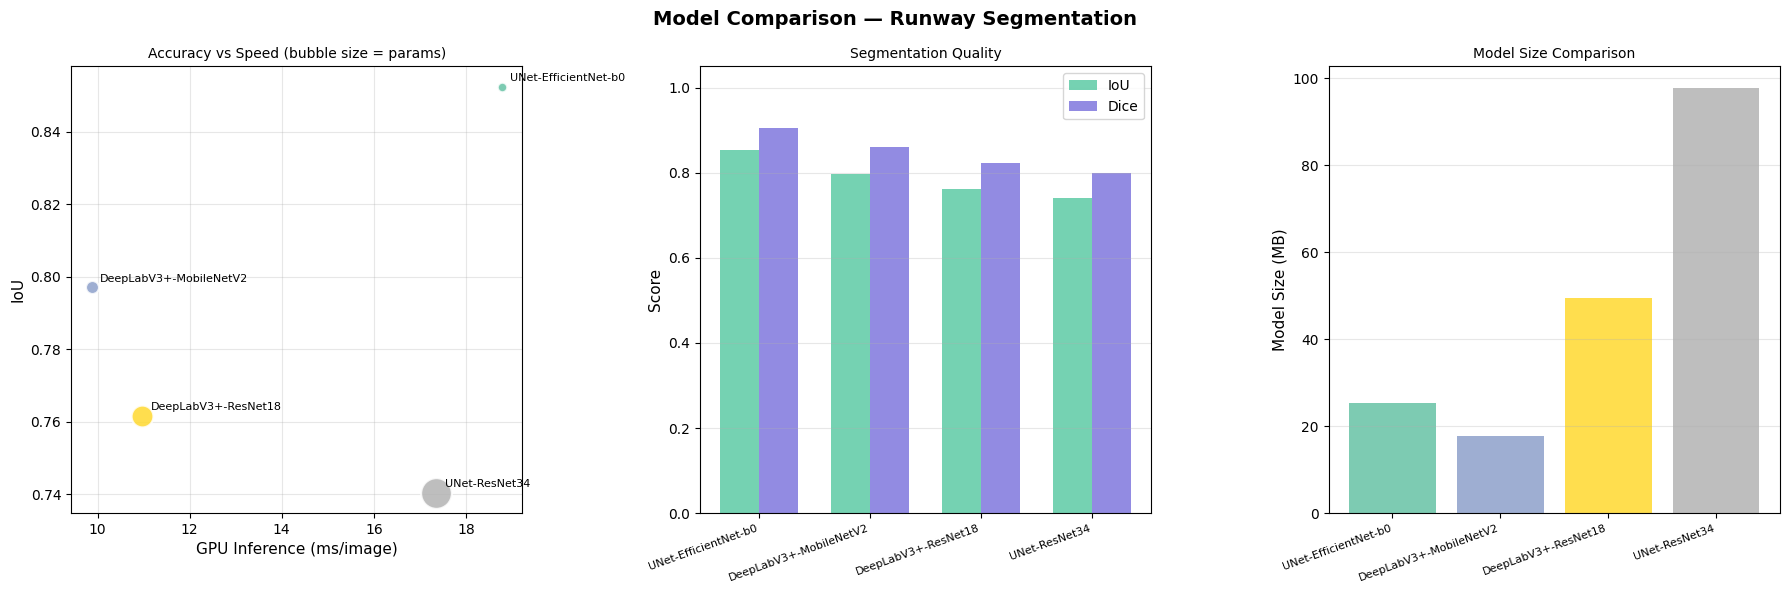


Plot saved → /content/drive/MyDrive/EAI_Runway_Segmentation/phase1_comparison.png


In [ ]:
# ── CELL 11: Visualizations ───────────────────────────────────────────────────
if len(results) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Model Comparison — Runway Segmentation", fontsize=14, fontweight="bold")

    models = list(df["Model"])
    colors = plt.cm.Set2(np.linspace(0, 1, len(models)))

    # ── Plot 1: Pareto — IoU vs GPU ms ──
    ax = axes[0]
    for i, row in df.iterrows():
        ax.scatter(row["GPU ms"], row["IoU"], s=row["Params(M)"] * 20,
                   color=colors[i], zorder=3, alpha=0.85, edgecolors="white", linewidth=1.5)
        ax.annotate(row["Model"], (row["GPU ms"], row["IoU"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax.set_xlabel("GPU Inference (ms/image)", fontsize=11)
    ax.set_ylabel("IoU", fontsize=11)
    ax.set_title("Accuracy vs Speed (bubble size = params)", fontsize=10)
    ax.grid(alpha=0.3)

    # ── Plot 2: Accuracy metrics bar chart ──
    ax = axes[1]
    x     = np.arange(len(models))
    width = 0.35
    ax.bar(x - width/2, df["IoU"],  width, label="IoU",  color="#5DCAA5", alpha=0.85)
    ax.bar(x + width/2, df["Dice"], width, label="Dice", color="#7F77DD", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(df["Model"], rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title("Segmentation Quality", fontsize=10)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)

    # ── Plot 3: Size vs IoU ──
    ax = axes[2]
    for i, row in df.iterrows():
        ax.bar(row["Model"], row["Size(MB)"], color=colors[i], alpha=0.85)
    ax.set_ylabel("Model Size (MB)", fontsize=11)
    ax.set_title("Model Size Comparison", fontsize=10)
    ax.set_xticklabels(df["Model"], rotation=20, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(SAVE_DIR, "phase1_comparison.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nPlot saved → {fig_path}")


Generating qualitative comparison panel...


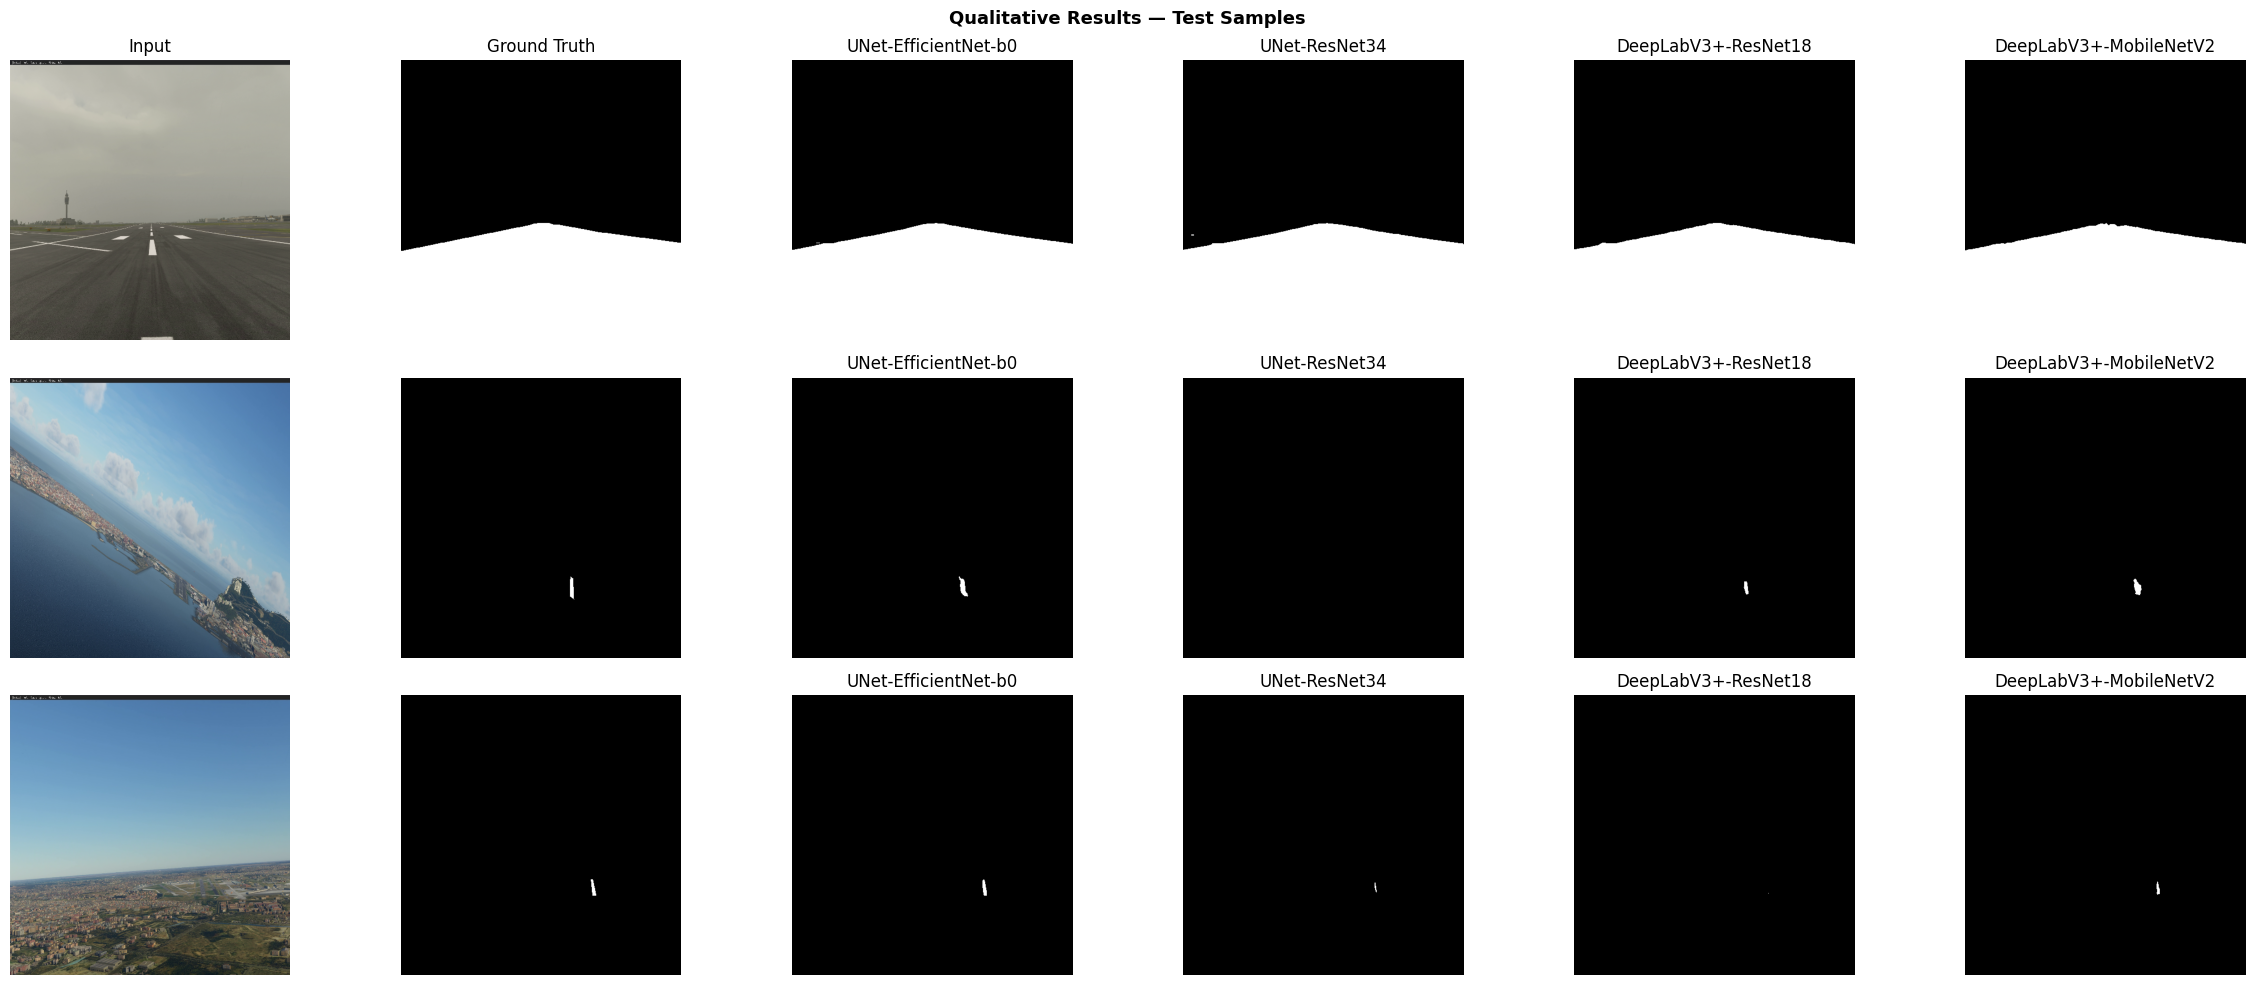

Qualitative panel saved → /content/drive/MyDrive/EAI_Runway_Segmentation/phase1_qualitative.png

Phase 1 COMPLETE
Results: /content/drive/MyDrive/EAI_Runway_Segmentation/phase1_results.json
Table:   /content/drive/MyDrive/EAI_Runway_Segmentation//phase1_table.csv
Next: Run phase2_pruning.py


In [ ]:
# ── CELL 12: Qualitative Predictions ─────────────────────────────────────────
print("\nGenerating qualitative comparison panel...")

# Pick a batch from test set
sample_imgs, sample_masks = next(iter(test_loader))
sample_imgs  = sample_imgs[:3]    # show 3 samples
sample_masks = sample_masks[:3]

n_models = len(results)
if n_models > 0:
    fig, axes = plt.subplots(3, n_models + 2, figsize=(4*(n_models+2), 10))
    fig.suptitle("Qualitative Results — Test Samples", fontsize=13, fontweight="bold")

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    for row in range(3):
        # Original image (denormalized)
        img_disp = (sample_imgs[row] * std + mean).permute(1,2,0).numpy().clip(0,1)
        axes[row][0].imshow(img_disp)
        axes[row][0].set_title("Input" if row == 0 else "")
        axes[row][0].axis("off")

        # Ground truth
        axes[row][1].imshow(sample_masks[row, 0].numpy(), cmap="gray")
        axes[row][1].set_title("Ground Truth" if row == 0 else "")
        axes[row][1].axis("off")

        # Each model's prediction
        for col, (mname, _) in enumerate(results.items()):
            try:
                m = build_model(mname)
                m.load_state_dict(torch.load(CHECKPOINT_MAP[mname], map_location="cpu"))
                m.eval()
                with torch.no_grad():
                    pred = torch.sigmoid(m(sample_imgs[row:row+1])) > 0.5
                pred_np = pred[0,0].numpy()
                axes[row][col+2].imshow(pred_np, cmap="gray")
                axes[row][col+2].set_title(mname)
                axes[row][col+2].axis("off")
            except Exception:
                axes[row][col+2].axis("off")

    plt.tight_layout()
    fig_path = os.path.join(SAVE_DIR, "phase1_qualitative.png")
    plt.savefig(fig_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Qualitative panel saved → {fig_path}")

print("\n" + "="*60)
print("Phase 1 COMPLETE")
print(f"Results: {results_path}")
print(f"Table:   {SAVE_DIR}/phase1_table.csv")
print("Next: Run phase2_pruning.py")
print("="*60)